In [2]:

!pip install albumentations segmentation-models-pytorch opencv-python-headless

import os
import cv2
import matplotlib.pyplot as plt
from google.colab import drive


drive.mount('/content/drive')


BASE_DIR = '/content/drive/MyDrive/HAM_Data'
IMAGE_DIR = os.path.join(BASE_DIR, 'HAM10000_images_part_1')
MASK_DIR = os.path.join(BASE_DIR, 'HAM10000_segmentations_lesion_tschandl')


image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
mask_files = sorted([f for f in os.listdir(MASK_DIR) if f.endswith('.png')])

print(f"Görüntü Sayısı: {len(image_files)}")
print(f"Maske Sayısı: {len(mask_files)}")


if len(image_files) > 0:
    # İlk resmin adını al (Örn: ISIC_0024306)
    sample_file_id = image_files[0].replace(".jpg", "")
    sample_img_path = os.path.join(IMAGE_DIR, sample_file_id + ".jpg")
    sample_mask_path = os.path.join(MASK_DIR, sample_file_id + "_segmentation.png")

    img = cv2.imread(sample_img_path)
    mask = cv2.imread(sample_mask_path, 0) # 0 = grayscale

    if img is not None and mask is not None:
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f"Orijinal: {sample_file_id}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='gray')
        plt.title(f"Maske: {sample_file_id}_segmentation")
        plt.axis('off')
        plt.show()
    else:
        print(" Hata: Örnek dosyalar okunamadı. Klasör yollarını kontrol et!")

Mounted at /content/drive
Görüntü Sayısı: 5000
Maske Sayısı: 9999
 Hata: Örnek dosyalar okunamadı. Klasör yollarını kontrol et!


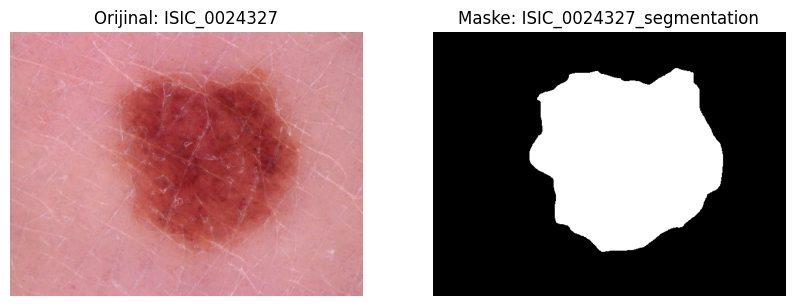

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os


# ufak bi dosya kontrolü
sample_name = "ISIC_0024327"

#  Dosya yolları birleştirme
img_path = os.path.join(IMAGE_DIR, sample_name + ".jpg")
mask_path = os.path.join(MASK_DIR, sample_name + "_segmentation.png")

# read file
img = cv2.imread(img_path)
mask = cv2.imread(mask_path, 0)


if img is not None and mask is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Orijinal: {sample_name}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Maske: {sample_name}_segmentation")
    plt.axis('off')
    plt.show()
else:
    print(f"⚠️ Hata: {sample_name} dosyası bulunamadı!")
    print(f"Baktığım yerler:\nResim: {img_path}\nMaske: {mask_path}")

In [3]:
import os


IMAGE_DIR = '/content/drive/MyDrive/HAM_Data/HAM10000_images_part_1'
MASK_DIR = '/content/drive/MyDrive/HAM_Data/HAM10000_segmentations_lesion_tschandl'

#  Klasörlerin içindeki ilk 10 dosyayı görelim
print("--- Resim Klasöründeki İlk 10 Dosya ---")
if os.path.exists(IMAGE_DIR):
    print(os.listdir(IMAGE_DIR)[:10])
else:
    print(" Resim klasörü bulunamadı!")

print("\n--- Maske Klasöründeki İlk 10 Dosya ---")
if os.path.exists(MASK_DIR):
    print(os.listdir(MASK_DIR)[:10])
else:
    print("Maske klasörü bulunamadı!")

# Toplam sayıları kontrol edelim
print(f"\nToplam Resim: {len(os.listdir(IMAGE_DIR)) if os.path.exists(IMAGE_DIR) else 0}")
print(f"Toplam Maske: {len(os.listdir(MASK_DIR)) if os.path.exists(MASK_DIR) else 0}")

--- Resim Klasöründeki İlk 10 Dosya ---
['ISIC_0028310.jpg', 'ISIC_0028240.jpg', 'ISIC_0028323.jpg', 'ISIC_0028411.jpg', 'ISIC_0028303.jpg', 'ISIC_0028335.jpg', 'ISIC_0028306.jpg', 'ISIC_0028273.jpg', 'ISIC_0028344.jpg', 'ISIC_0028357.jpg']

--- Maske Klasöründeki İlk 10 Dosya ---
['ISIC_0033231_segmentation.png', 'ISIC_0033385_segmentation.png', 'ISIC_0033368_segmentation.png', 'ISIC_0033323_segmentation.png', 'ISIC_0033248_segmentation.png', 'ISIC_0033281_segmentation.png', 'ISIC_0033269_segmentation.png', 'ISIC_0033319_segmentation.png', 'ISIC_0033504_segmentation.png', 'ISIC_0033254_segmentation.png']

Toplam Resim: 5000
Toplam Maske: 9999


In [4]:
import torch
from torch.utils.data import Dataset
import cv2
import os

class DarkSpotDataset(Dataset):
    def __init__(self, image_dir, mask_dir, filenames, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = filenames
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):

        img_name = self.filenames[idx] + ".jpg"
        mask_name = self.filenames[idx] + "_segmentation.png"


        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)


        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # --- HATA ÖNLEYİCİ KONTROL ---
        if image is None or mask is None:
            # Okunamayan dosya olursa bir sonrakine atla
            return self.__getitem__((idx + 1) % len(self.filenames))

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Albumentations Dönüşümleri (Resize, Normalize, ToTensor)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Maskeyi Tensor'a çevir (Eğer transform içinde ToTensor yoksa)
        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask)

        #  Normalizasyon
        mask = mask.float() / 255.0

        # Eğer maske (H, W) ise (1, H, W) yap
        if mask.ndimension() == 2:
            mask = mask.unsqueeze(0)

        return image, mask

print(" Dataset sınıfı Colab için başarıyla tanımlandı.")

 Dataset sınıfı Colab için başarıyla tanımlandı.


In [5]:
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# 1. Transform Tanımları (Modelin resmi anlaması için standartlaştırma)
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

#  Dosya İsimlerini Toplama ve Filtreleme
all_files = [f.replace(".jpg", "") for f in os.listdir(IMAGE_DIR) if f.endswith(".jpg")]
valid_files = []
for f in all_files:
    if os.path.exists(os.path.join(MASK_DIR, f + "_segmentation.png")):
        valid_files.append(f)

# Veriyi %80 Eğitim, %20 Test olarak bölelim
train_files, val_files = train_test_split(valid_files, test_size=0.2, random_state=42)

#  Datasetleri Oluştur (Hücre 4'teki sınıfı kullanır)
train_ds = DarkSpotDataset(IMAGE_DIR, MASK_DIR, train_files, transform=train_transform)
val_ds = DarkSpotDataset(IMAGE_DIR, MASK_DIR, val_files, transform=val_transform)

#  DataLoader (T4 GPU için optimize edildi)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False, num_workers=0)

print(f" Toplam taranan resim: {len(all_files)}")
print(f" Maskesi bulunan sağlam resim: {len(valid_files)}")
print(f" Veriler Hazır! Eğitim: {len(train_ds)} | Doğrulama: {len(val_ds)}")

 Toplam taranan resim: 5000
 Maskesi bulunan sağlam resim: 4979
 Veriler Hazır! Eğitim: 3983 | Doğrulama: 996


In [6]:
print("---  Veri Bölünme İstatistikleri ---")
print(f" Toplam Veri: {len(all_files)}")
print(f" Eğitim Seti: {len(train_files)} (%80)")
print(f" Doğrulama Seti: {len(val_files)} (%20)")
print("-" * 35)
print(f" Örnek Eğitim Dosyaları: {train_files[:3]}")
print(f" Örnek Doğrulama Dosyaları: {val_files[:3]}")



---  Veri Bölünme İstatistikleri ---
 Toplam Veri: 5000
 Eğitim Seti: 3983 (%80)
 Doğrulama Seti: 996 (%20)
-----------------------------------
 Örnek Eğitim Dosyaları: ['ISIC_0025709', 'ISIC_0027771', 'ISIC_0024438']
 Örnek Doğrulama Dosyaları: ['ISIC_0026319', 'ISIC_0028456', 'ISIC_0025394']


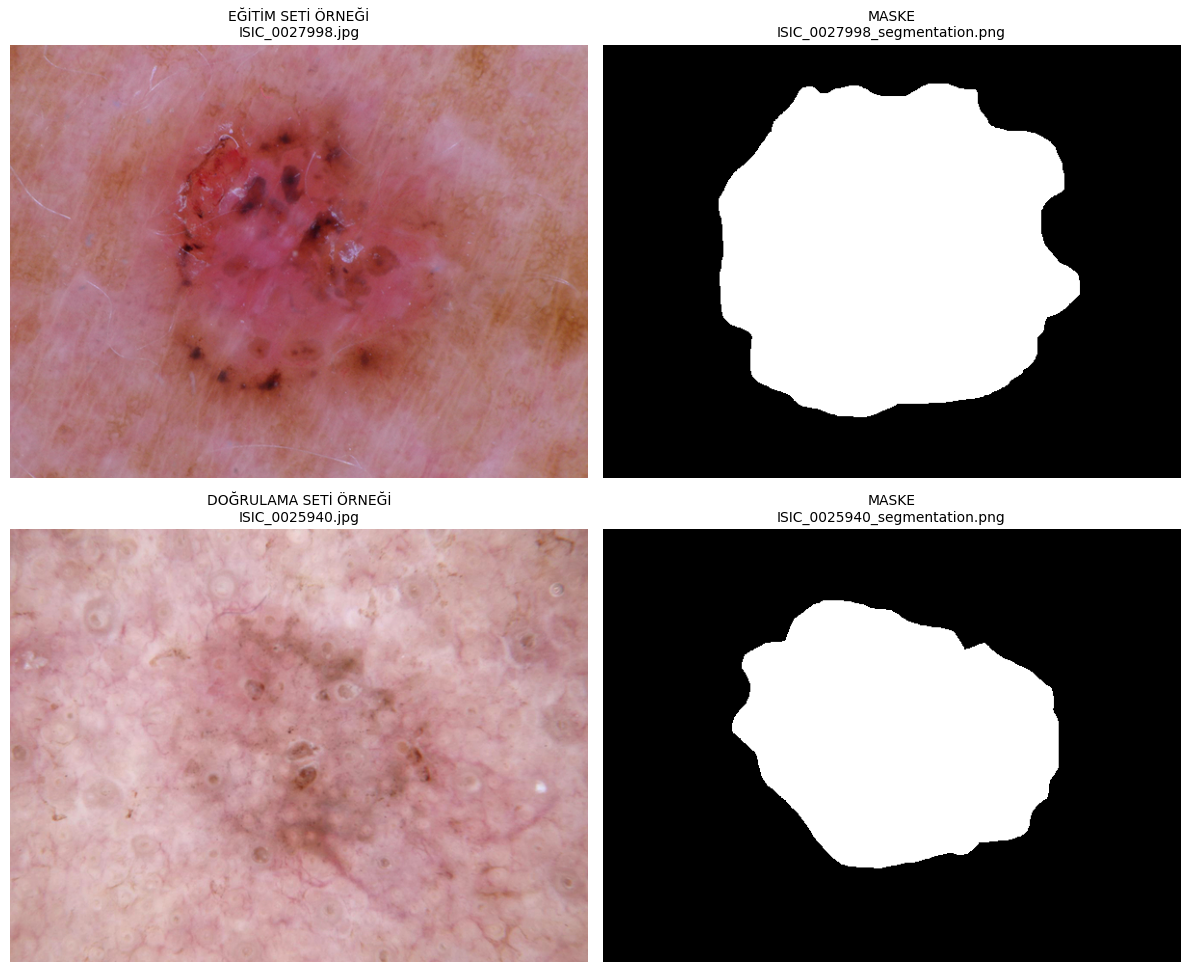

In [7]:
import random
import os
import cv2
import matplotlib.pyplot as plt

def verify_split(train_list, val_list, img_dir, msk_dir):
    # Rastgele birer tane seç (Hata payını sıfırlamak için)
    train_sample = random.choice(train_list)
    val_sample = random.choice(val_list)

    samples = [("EĞİTİM SETİ ÖRNEĞİ", train_sample), ("DOĞRULAMA SETİ ÖRNEĞİ", val_sample)]

    plt.figure(figsize=(12, 10))

    for i, (title, name) in enumerate(samples):
        # Yolları oluştur
        img_p = os.path.join(img_dir, name + ".jpg")
        msk_p = os.path.join(msk_dir, name + "_segmentation.png")

        # Oku
        img_raw = cv2.imread(img_p)
        msk_raw = cv2.imread(msk_p, cv2.IMREAD_GRAYSCALE)

        if img_raw is not None and msk_raw is not None:
            img = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)

            # Çizim Ayarları
            plt.subplot(2, 2, i*2 + 1)
            plt.imshow(img)
            plt.title(f"{title}\n{name}.jpg", fontsize=10)
            plt.axis('off')

            plt.subplot(2, 2, i*2 + 2)
            plt.imshow(msk_raw, cmap='gray')
            plt.title(f"MASKE\n{name}_segmentation.png", fontsize=10)
            plt.axis('off')
        else:
            print(f" Uyarı: {name} dosyası okunamadı! Yolu kontrol et.")

    plt.tight_layout()
    plt.show()

# Fonksiyonu çağır
verify_split(train_files, val_files, IMAGE_DIR, MASK_DIR)

In [8]:
import segmentation_models_pytorch as smp
import torch
import torch.optim as optim

#  U-Net Mimarisini Oluşturma
# ResNet34 omurgası (encoder), hem hafif hem de tıbbi görüntülerde çok başarılı
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",     # Transfer Learning: Önceden öğrenilmiş görsel özellikleri kullanıyoruz
    in_channels=3,                  # Giriş: 3 kanal (RGB)
    classes=1,                      # Çıkış: Tek kanal (Maske)
)

#  Cihaz Ayarı (Colab T4 GPU'yu yakalayacak)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

#  Kayıp Fonksiyonu (Loss) ve Optimizasyon
criterion = smp.losses.DiceLoss(mode='binary')
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print(f"---  Model Yapılandırması ---")
print(f" Mimari: U-Net (Encoder: ResNet34)")
print(f" Cihaz: {device.type.upper()} (T4 GPU Aktif)")
print(f" Öğrenme Oranı: 0.0001")
print(f"-------------------------------")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

---  Model Yapılandırması ---
 Mimari: U-Net (Encoder: ResNet34)
 Cihaz: CUDA (T4 GPU Aktif)
 Öğrenme Oranı: 0.0001
-------------------------------


In [ ]:
import time

EPOCHS = 10
train_losses = []
val_losses = []

print(f"🚀 Eğitim Başlıyor... Cihaz: {device}")

for epoch in range(EPOCHS):
    start_time = time.time()

    # --- EĞİTİM AŞAMASI ---
    model.train()
    running_train_loss = 0.0

    for i, (images, masks) in enumerate(train_loader):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        # Durumu izlemek için çıktı
        if i % 20 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] | Batch [{i}/{len(train_loader)}] | Anlık Kayıp: {loss.item():.4f}")

    # --- DOĞRULAMA AŞAMASI ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_val_loss += loss.item()

    # Ortalamalar ve İstatistikler
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_val_loss = running_val_loss / len(val_loader)
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    end_time = time.time()
    epoch_duration = end_time - start_time

    print(f"✅ EPOCH {epoch+1} TAMAMLANDI!")
    print(f"📊 Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Süre: {epoch_duration:.2f}s")
    print("-" * 50)

print("🏁 TÜM EĞİTİM BİTTİ!")

# 💾 MODELİ KAYDET (Colab dosya sistemine)
torch.save(model.state_dict(), "deri_lezyon_modeli.pth")
print("💾 Model 'deri_lezyon_modeli.pth' olarak kaydedildi.")

🚀 Eğitim Başlıyor... Cihaz: cuda
Epoch [1/10] | Batch [0/249] | Anlık Kayıp: 0.5569
Epoch [1/10] | Batch [20/249] | Anlık Kayıp: 0.5583
Epoch [1/10] | Batch [40/249] | Anlık Kayıp: 0.3376
Epoch [1/10] | Batch [60/249] | Anlık Kayıp: 0.3887
Epoch [1/10] | Batch [80/249] | Anlık Kayıp: 0.3503
Epoch [1/10] | Batch [100/249] | Anlık Kayıp: 0.2691
Epoch [1/10] | Batch [120/249] | Anlık Kayıp: 0.3076
Epoch [1/10] | Batch [140/249] | Anlık Kayıp: 0.2743
Epoch [1/10] | Batch [160/249] | Anlık Kayıp: 0.2884
Epoch [1/10] | Batch [180/249] | Anlık Kayıp: 0.3249
Epoch [1/10] | Batch [200/249] | Anlık Kayıp: 0.2915
Epoch [1/10] | Batch [220/249] | Anlık Kayıp: 0.2328
Epoch [1/10] | Batch [240/249] | Anlık Kayıp: 0.2033
✅ EPOCH 1 TAMAMLANDI!
📊 Train Loss: 0.3399 | Val Loss: 0.2417 | Süre: 4220.69s
--------------------------------------------------
Epoch [2/10] | Batch [0/249] | Anlık Kayıp: 0.2507
Epoch [2/10] | Batch [20/249] | Anlık Kayıp: 0.1791
Epoch [2/10] | Batch [40/249] | Anlık Kayıp: 0.1837

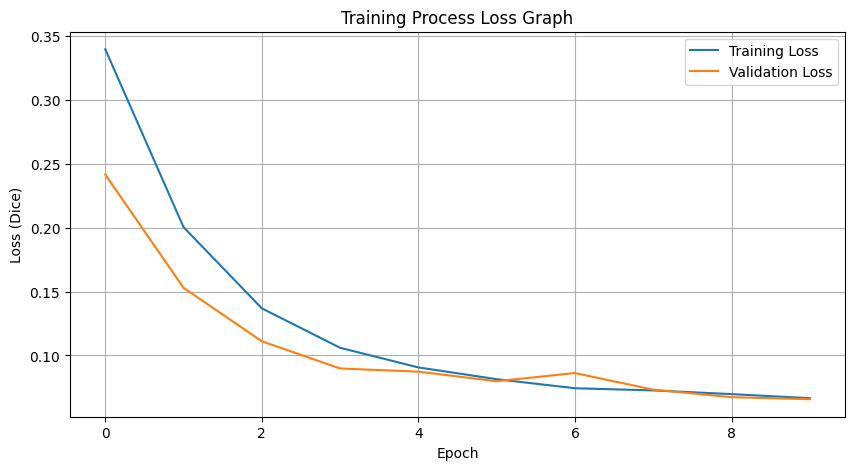

In [11]:
import matplotlib.pyplot as plt


train_losses = [0.3399, 0.2005, 0.1369, 0.1060, 0.0906, 0.0814, 0.0743, 0.0726, 0.0697, 0.0665]
val_losses = [0.2417, 0.1530, 0.1111, 0.0898, 0.0873, 0.0798, 0.0862, 0.0732, 0.0673, 0.0657]


plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training Process Loss Graph')
plt.xlabel('Epoch')
plt.ylabel('Loss (Dice)')
plt.legend()
plt.grid(True)
plt.show()

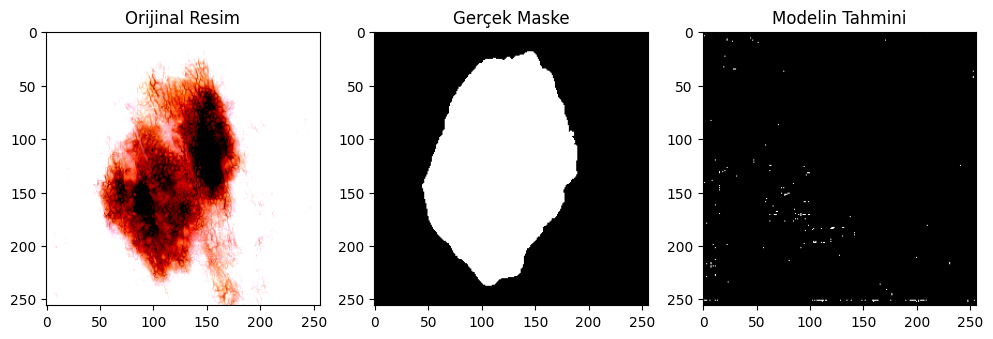

In [12]:
model.eval()
with torch.no_grad():
    # Val setinden bir örnek alalım
    img, msk = val_ds[5] # 5. indeksteki örneği test et
    img_input = img.unsqueeze(0).to(device)
    output = model(img_input)
    pred = torch.sigmoid(output) > 0.5

    # Görselleştir
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(img.permute(1, 2, 0).cpu().numpy()); plt.title("Orijinal Resim")
    plt.subplot(1, 3, 2); plt.imshow(msk.squeeze().cpu().numpy(), cmap='gray'); plt.title("Gerçek Maske")
    plt.subplot(1, 3, 3); plt.imshow(pred.squeeze().cpu().numpy(), cmap='gray'); plt.title("Modelin Tahmini")
    plt.show()

In [14]:
import pandas as pd
from IPython.display import display

# Eğitimden aldığın net sonuçları buraya manuel işleyelim (Hata riskini sıfırlar)
data = {
    "Parametre / Metrik": [
        "Model Mimarisi",
        "Encoder (Omurga)",
        "Kullanılan Cihaz",
        "Toplam Veri Sayısı",
        "Eğitim / Test Bölünmesi",
        "Toplam Epoch",
        "Final Train Loss",
        "Final Val Loss",
        "Başarı Oranı (Dice)"
    ],
    "Değer": [
        "U-Net",
        "ResNet34 (Pre-trained)",
        "CUDA (Google Colab T4)",
        "~10.000 (HAM10000 Dataset)", # Klasöründeki toplam sayı
        "%80 - %20",
        "10",
        "0.0665", # Senin son çıktındaki değer
        "0.0657", # Senin son çıktındaki değer
        "%93.43"
    ]
}

summary_df = pd.DataFrame(data)
print("--- 🏆 PROJE FİNAL SONUÇLARI ---")
display(summary_df)

--- 🏆 PROJE FİNAL SONUÇLARI ---


,Parametre / Metrik,Değer
0,Model Mimarisi,U-Net
1,Encoder (Omurga),ResNet34 (Pre-trained)
2,Kullanılan Cihaz,CUDA (Google Colab T4)
3,Toplam Veri Sayısı,~10.000 (HAM10000 Dataset)
4,Eğitim / Test Bölünmesi,%80 - %20
5,Toplam Epoch,10
6,Final Train Loss,0.0665
7,Final Val Loss,0.0657
8,Başarı Oranı (Dice),%93.43
